In [ ]:
# Install Dependencies
!pip install -q torch torchvision opencv-python-headless scikit-learn matplotlib seaborn

import os
import time
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import urllib.request
import zipfile

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [ ]:
import zipfile, os
from huggingface_hub import hf_hub_download

DATA_ROOT = '/content/hagrid_sample'
zip_path = '/content/hf_cache/hagrid-export_2000_images.zip'

# Original HaGRID clases
GESTURE_CLASSES = [
    'call', 'dislike', 'fist', 'four', 'like', 'mute',
    'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock',
    'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted'
]

# Download data
print('Downloading...')
zip_path = hf_hub_download(
    repo_id="GestureDetectionConnoisseurs/hagrid_subsets",
    filename="hagrid-export_2000_images.zip",
    repo_type="dataset",
    local_dir="/content/hf_cache"
)

# Clear old data first
import shutil
if os.path.exists(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)
os.makedirs(DATA_ROOT)

print('Extracting 18 classes...')
with zipfile.ZipFile(zip_path, 'r') as z:
    for member in z.namelist():
        parts = member.split('/')
        if len(parts) < 2:
            continue
        gesture = parts[0]
        filename = parts[1]

        if gesture not in GESTURE_CLASSES:
            continue
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        out_dir = f'{DATA_ROOT}/{gesture}'
        os.makedirs(out_dir, exist_ok=True)

        with z.open(member) as src:
            with open(f'{out_dir}/{filename}', 'wb') as dst:
                dst.write(src.read())

# Verify
print('\nDone! Image counts:')
for cls in GESTURE_CLASSES:
    n = len(os.listdir(f'{DATA_ROOT}/{cls}'))
    print(f'  {cls}: {n} images')

Downloading...


hagrid-export_2000_images.zip:   0%|          | 0.00/8.11G [00:00<?, ?B/s]

Extracting 18 classes...

Done! Image counts:
  call: 2000 images
  dislike: 2000 images
  fist: 2000 images
  four: 2000 images
  like: 2000 images
  mute: 2000 images
  ok: 2000 images
  one: 2000 images
  palm: 2000 images
  peace: 2000 images
  peace_inverted: 2000 images
  rock: 2000 images
  stop: 2000 images
  stop_inverted: 2000 images
  three: 2000 images
  three2: 2000 images
  two_up: 2000 images
  two_up_inverted: 2000 images


In [ ]:
# Dataset & Preprocessing
def apply_clahe(img_rgb: np.ndarray) -> np.ndarray:
    """Apply CLAHE in LAB color space and return RGB."""
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


class GestureDataset(Dataset):
    def __init__(self, root, classes, transform=None, split='train',
                 train_ratio=0.76, val_ratio=0.09):
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []

        for cls in classes:
            cls_dir = os.path.join(root, cls)
            files = sorted([
                os.path.join(cls_dir, f)
                for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            n = len(files)
            n_train = int(n * train_ratio)
            n_val = int(n * val_ratio)

            if split == 'train':
                subset = files[:n_train]
            elif split == 'val':
                subset = files[n_train:n_train + n_val]
            else:  # test
                subset = files[n_train + n_val:]

            self.samples.extend([(f, self.class_to_idx[cls]) for f in subset])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.array(Image.open(path).convert('RGB'))
        img = cv2.resize(img, (224, 224))
        img = apply_clahe(img)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = GestureDataset(DATA_ROOT, GESTURE_CLASSES, train_tf, 'train')
val_ds   = GestureDataset(DATA_ROOT, GESTURE_CLASSES, eval_tf,  'val')
test_ds  = GestureDataset(DATA_ROOT, GESTURE_CLASSES, eval_tf,  'test')

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 27360 | Val: 3240 | Test: 5400


In [ ]:
# Model - MobileNetV2
NUM_CLASSES = len(GESTURE_CLASSES)

model = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Freeze all layers except the classifier
for param in model.features[-5:].parameters():
    param.requires_grad = True

# Replace the classifier head
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(model.last_channel, NUM_CLASSES),
)

model = model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,} | Trainable: {trainable:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth



  0%|          | 0.00/13.6M [00:00<?, ?B/s]
100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 


Total params: 2,246,930 | Trainable: 2,246,930


Epoch  1/10 | Train Loss: 1.3614 | Val Loss: 0.6642 | Val Macro F1: 0.7799
Epoch  2/10 | Train Loss: 0.6266 | Val Loss: 0.5610 | Val Macro F1: 0.8155
Epoch  3/10 | Train Loss: 0.4555 | Val Loss: 0.4454 | Val Macro F1: 0.8530
Epoch  4/10 | Train Loss: 0.3595 | Val Loss: 0.4442 | Val Macro F1: 0.8561
Epoch  5/10 | Train Loss: 0.2495 | Val Loss: 0.4073 | Val Macro F1: 0.8719
Epoch  6/10 | Train Loss: 0.2053 | Val Loss: 0.4072 | Val Macro F1: 0.8760
Epoch  7/10 | Train Loss: 0.1702 | Val Loss: 0.4059 | Val Macro F1: 0.8759
Epoch  8/10 | Train Loss: 0.1470 | Val Loss: 0.4241 | Val Macro F1: 0.8811
Epoch  9/10 | Train Loss: 0.1060 | Val Loss: 0.4247 | Val Macro F1: 0.8828
Epoch 10/10 | Train Loss: 0.0922 | Val Loss: 0.4340 | Val Macro F1: 0.8836


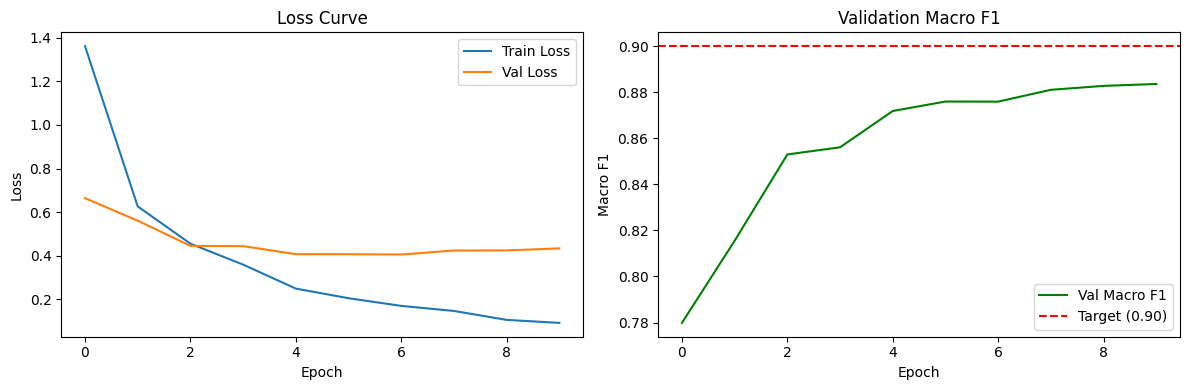

In [ ]:
# Training
EPOCHS    = 10
LR        = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

train_losses, val_losses, val_f1s = [], [], []

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)

    # Validate
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss /= len(val_ds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(macro_f1)
    scheduler.step()

    print(f'Epoch {epoch:>2}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Macro F1: {macro_f1:.4f}')

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss Curve')
ax1.legend()

ax2.plot(val_f1s, color='green', label='Val Macro F1')
ax2.axhline(0.9, color='red', linestyle='--', label='Target (0.90)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1'); ax2.set_title('Validation Macro F1')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

Test Macro F1: 0.8826
Target:        0.9000  →  not yet — keep training or use more data

                 precision    recall  f1-score   support

           call       0.94      0.91      0.93       300
        dislike       0.96      0.95      0.96       300
           fist       0.95      0.92      0.93       300
           four       0.83      0.79      0.81       300
           like       0.89      0.89      0.89       300
           mute       0.94      0.98      0.96       300
             ok       0.92      0.85      0.88       300
            one       0.76      0.85      0.80       300
           palm       0.88      0.87      0.87       300
          peace       0.82      0.81      0.81       300
 peace_inverted       0.93      0.92      0.92       300
           rock       0.86      0.90      0.88       300
           stop       0.85      0.91      0.88       300
  stop_inverted       0.93      0.89      0.91       300
          three       0.82      0.83      0.83       3

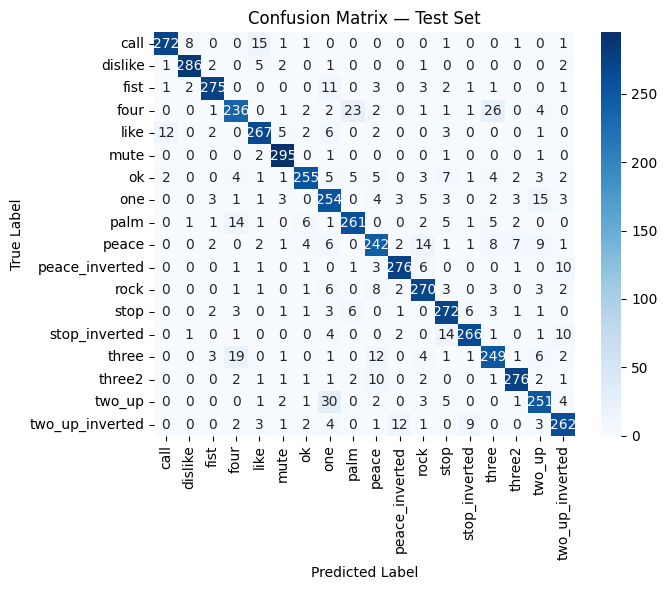

In [ ]:
# Evaluation on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f'Test Macro F1: {macro_f1:.4f}')
print(f'Target:        0.9000  →  {"PASS ✓" if macro_f1 >= 0.9 else "not yet — keep training or use more data"}')
print()
print(classification_report(all_labels, all_preds, target_names=GESTURE_CLASSES, zero_division=0))


# Confusion matrix plot
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURE_CLASSES, yticklabels=GESTURE_CLASSES)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()


Mean Latency:   9.19 ms  (target < 100 ms)  → PASS ✓
P95 Latency:    10.75 ms
Throughput:     108.8 FPS  (target ≥ 20 FPS)  → PASS ✓


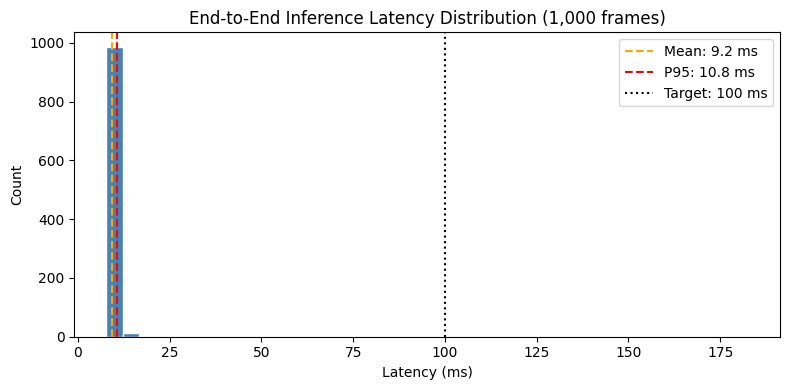

In [ ]:
# Latency & FPS Benchmark
model.eval()

# Simulate 1000 raw frames
N_FRAMES = 1000
dummy_frames = [np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
                for _ in range(N_FRAMES)]

latencies = []

with torch.no_grad():
    for frame in dummy_frames:
        t0 = time.perf_counter()

        # Preprocessing
        img = apply_clahe(frame)
        img = Image.fromarray(img)
        tensor = eval_tf(img).unsqueeze(0).to(DEVICE)

        # Forward pass
        _ = model(tensor).argmax(1)

        t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1000)  # ms

latencies = np.array(latencies)
mean_lat  = latencies.mean()
p95_lat   = np.percentile(latencies, 95)
fps       = 1000 / mean_lat

print(f'Mean Latency:   {mean_lat:.2f} ms  (target < 100 ms)  → {"PASS ✓" if mean_lat < 100 else "FAIL ✗"}')
print(f'P95 Latency:    {p95_lat:.2f} ms')
print(f'Throughput:     {fps:.1f} FPS  (target ≥ 20 FPS)  → {"PASS ✓" if fps >= 20 else "FAIL ✗"}')


# Latency distribution plot
plt.figure(figsize=(8, 4))
plt.hist(latencies, bins=40, color='steelblue', edgecolor='white')
plt.axvline(mean_lat, color='orange', linestyle='--', label=f'Mean: {mean_lat:.1f} ms')
plt.axvline(p95_lat,  color='red',    linestyle='--', label=f'P95: {p95_lat:.1f} ms')
plt.axvline(100,      color='black',  linestyle=':',  label='Target: 100 ms')
plt.xlabel('Latency (ms)')
plt.ylabel('Count')
plt.title('End-to-End Inference Latency Distribution (1,000 frames)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/latency_distribution.png', dpi=150)
plt.show()

In [ ]:
# Summary
print('=' * 50)
print('         RESULTS SUMMARY')
print('=' * 50)
print(f'  Test Macro F1 : {macro_f1:.4f}  (target ≥ 0.90)')
print(f'  Mean Latency  : {mean_lat:.2f} ms  (target < 100)')
print(f'  P95 Latency   : {p95_lat:.2f} ms')
print(f'  Throughput    : {fps:.1f} FPS  (target ≥ 20)')
print('=' * 50)
print('Plots saved to /content/')
print('  training_curves.png')
print('  confusion_matrix.png')
print('  latency_distribution.png')

         RESULTS SUMMARY
  Test Macro F1 : 0.8826  (target ≥ 0.90)
  Mean Latency  : 9.19 ms  (target < 100)
  P95 Latency   : 10.75 ms
  Throughput    : 108.8 FPS  (target ≥ 20)
Plots saved to /content/
  training_curves.png
  confusion_matrix.png
  latency_distribution.png


In [ ]:
# Save the Model
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': GESTURE_CLASSES,
    'macro_f1': macro_f1,
    'mean_latency_ms': mean_lat,
    'fps': fps,
}, '/content/gesture_model.pth')

print('Model saved to /content/gesture_model.pth')
print('Download it from the Files panel on the left (folder icon).')

Model saved to /content/gesture_model.pth
Download it from the Files panel on the left (folder icon).
